In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [3]:
df=pd.read_csv("customer_retail csv file.csv")

In [4]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [5]:
df=df.dropna()

In [6]:
df=df[['Quantity','UnitPrice','Country']]

In [8]:
encoder=LabelEncoder()
df['Country_encoded']=encoder.fit_transform(df['Country'])

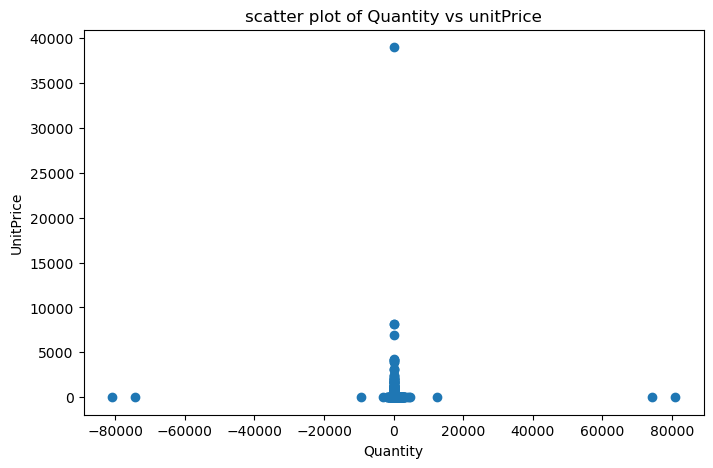

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('scatter plot of Quantity vs unitPrice')
plt.show()

In [13]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Logistic Regression")
log_model=LogisticRegression()
log_model.fit(x_train,y_train)
y_pred=log_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Logistic Regression
Accuracy: 0.8897328122311531
Confusion Matrix:
[[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0 72394     0]
 [    0     0     0 ...     0    43     0]]


C:\Users\kalya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
print("Decision Tree")
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))

Decision Tree
Accuracy: 0.8903473195192095
[[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   21     0     0 ...     1 72222     0]
 [    0     0     0 ...     0    43     0]]


In [15]:
print("KNN")
knn_model=KNeighborsClassifier()
knn_model.fit(x_train,y_train)
y_pred=knn_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))

KNN
Accuracy: 0.8851977484452965
[[   18     0     0 ...     0   180     0]
 [    0     1     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   36     1     0 ...     0 71772     0]
 [    0     0     0 ...     0    43     0]]


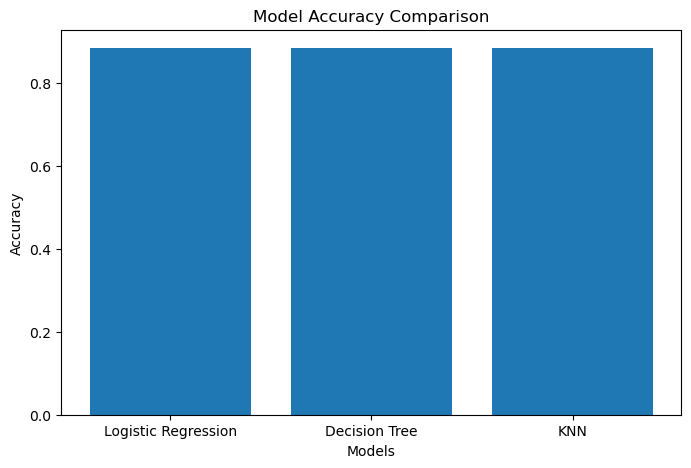

In [20]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    accuracy,
    accuracy,
    accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.show()

In [21]:
import os
print(os.getcwd())

C:\Users\kalya
